# GOES ABI SO2 / Volcanic Emissions RGB

Also infrared based, so it works day and night. It is a qualitative gas view, not a concentration retrieval.

Everything is in this notebook: the folder your files are in, the box
you choose, and the whole plotting code. Change any of it and re-run.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/);
nothing is downloaded here.

**Steps:** point at your folder -> plot the whole scan -> set your box -> plot
that box.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, display
from shapely.geometry import box as shapely_box

sys.path.insert(0, "..")
import goestools as gt


In [2]:
# ---------------------------------------------------------------
# Settings come from config.yml at the repository root. Override any of them
# in the next few lines if you want a one-off change.
# ---------------------------------------------------------------
CONFIG = yaml.safe_load(open("../config.yml"))
style = CONFIG["style"]

COAST_COLOUR = style["coast_colour"]
COAST_WIDTH = style["coast_width"]
COAST_RES = style["coast_resolution"]

GRID_COLOUR = style["grid_colour"]
GRID_ALPHA = style["grid_alpha"]
GRID_STYLE = style["grid_style"]
GRID_WIDTH = style["grid_width"]

MARKER_LON = style["marker_lon"]          # None hides the marker
MARKER_LAT = style["marker_lat"]
MARKER_COLOUR = style["marker_colour"]
MARKER_SIZE = style["marker_size"]

FIG_WIDTH = style["figure_width"]
DPI = style["dpi"]
STRIDE = style["overview_stride"]         # every n-th pixel for the whole scan


In [3]:
# ---------------------------------------------------------------
# Kept here so you can change them: coastlines clipped to a box, and the
# degree labels on the axes.
# ---------------------------------------------------------------
def coastlines(west, east, south, north, resolution="10m"):
    clip = shapely_box(west, south, east, north)
    segments = []
    feature = cfeature.NaturalEarthFeature("physical", "coastline", resolution)
    for geometry in feature.intersecting_geometries([west, east, south, north]):
        piece = geometry.intersection(clip)
        for line in (piece.geoms if hasattr(piece, "geoms") else [piece]):
            if not line.is_empty and line.length > 0:
                x, y = line.xy
                segments.append((np.asarray(x), np.asarray(y)))
    return segments


def lon_label(value, _pos=None):
    v = ((value + 180) % 360) - 180
    return f"{abs(v):g}\u00b0{'E' if v >= 0 else 'W'}"


def lat_label(value, _pos=None):
    return f"{abs(value):g}\u00b0{'N' if value >= 0 else 'S'}"


def decorate(ax, west, east, south, north, left_title, when):
    """Coastlines, graticule, degree labels and the two-part header."""
    ax.grid(color=GRID_COLOUR, alpha=GRID_ALPHA, ls=GRID_STYLE, lw=GRID_WIDTH,
            zorder=1)
    for x, y in coastlines(west, east, south, north, COAST_RES):
        ax.plot(x, y, color=COAST_COLOUR, lw=COAST_WIDTH, zorder=4)
    if MARKER_LON is not None and west <= MARKER_LON <= east and south <= MARKER_LAT <= north:
        ax.plot(MARKER_LON, MARKER_LAT, "^", color=MARKER_COLOUR,
                ms=MARKER_SIZE, zorder=6)
    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lon_label))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lat_label))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(left_title, loc="left")
    if when is not None:
        ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")


def figure_for(west, east, south, north):
    height = FIG_WIDTH * (north - south) / (east - west) * 0.92
    return plt.subplots(figsize=(FIG_WIDTH, max(3.0, min(12.0, height))))


## 1. Your files

In [4]:
# ---------------------------------------------------------------
# 1. YOUR FILES -- point this at the folder holding your NetCDF files
# ---------------------------------------------------------------
DATA_DIR = Path("..") / CONFIG["data"]["full_disk"]
CHANNELS = ["C09", "C10", "C11", "C13"]

files = sorted(glob.glob(str(DATA_DIR / "*.nc")))
print(f"folder: {DATA_DIR}")
print(f"{len(files)} file(s):")
for name in files:
    print("   ", Path(name).name)

# All of these must come from the SAME scan.
paths = gt.find_channels(files, CHANNELS)     # raises if a channel is missing
print("\nusing:", ", ".join(f"{c} -> {Path(p).name[:32]}..." for c, p in paths.items()))


folder: ../data/full_disk
10 file(s):
    OR_ABI-L1b-RadF-M6C01_G18_s20232761900206_e20232761909514_c20232761909554.nc
    OR_ABI-L1b-RadF-M6C02_G18_s20232761900206_e20232761909514_c20232761909546.nc
    OR_ABI-L1b-RadF-M6C03_G18_s20232761900206_e20232761909514_c20232761909559.nc
    OR_ABI-L1b-RadF-M6C07_G18_s20232761900206_e20232761909526_c20232761909567.nc
    OR_ABI-L1b-RadF-M6C09_G18_s20232761900206_e20232761909520_c20232761909561.nc
    OR_ABI-L1b-RadF-M6C10_G18_s20232761900206_e20232761909526_c20232761909548.nc
    OR_ABI-L1b-RadF-M6C11_G18_s20232761900206_e20232761909514_c20232761909558.nc
    OR_ABI-L1b-RadF-M6C13_G18_s20232761900206_e20232761909526_c20232761909572.nc
    OR_ABI-L1b-RadF-M6C14_G18_s20232761900206_e20232761909514_c20232761909569.nc
    OR_ABI-L1b-RadF-M6C15_G18_s20232761900206_e20232761909520_c20232761909555.nc

using: C09 -> OR_ABI-L1b-RadF-M6C09_G18_s20232..., C10 -> OR_ABI-L1b-RadF-M6C10_G18_s20232..., C11 -> OR_ABI-L1b-RadF-M6C11_G18_s20232..., C13 -> OR_AB

## 2. The whole scan

Every n-th pixel (`STRIDE`) for speed. Channels at 0.5, 1 and 2 km are lined up
by averaging the finer one down by an exact integer factor, so nothing is
interpolated.

<Composite SO2 / Volcanic Emissions RGB (678, 678, 3) at 2023-10-03 19:00:20.655517>


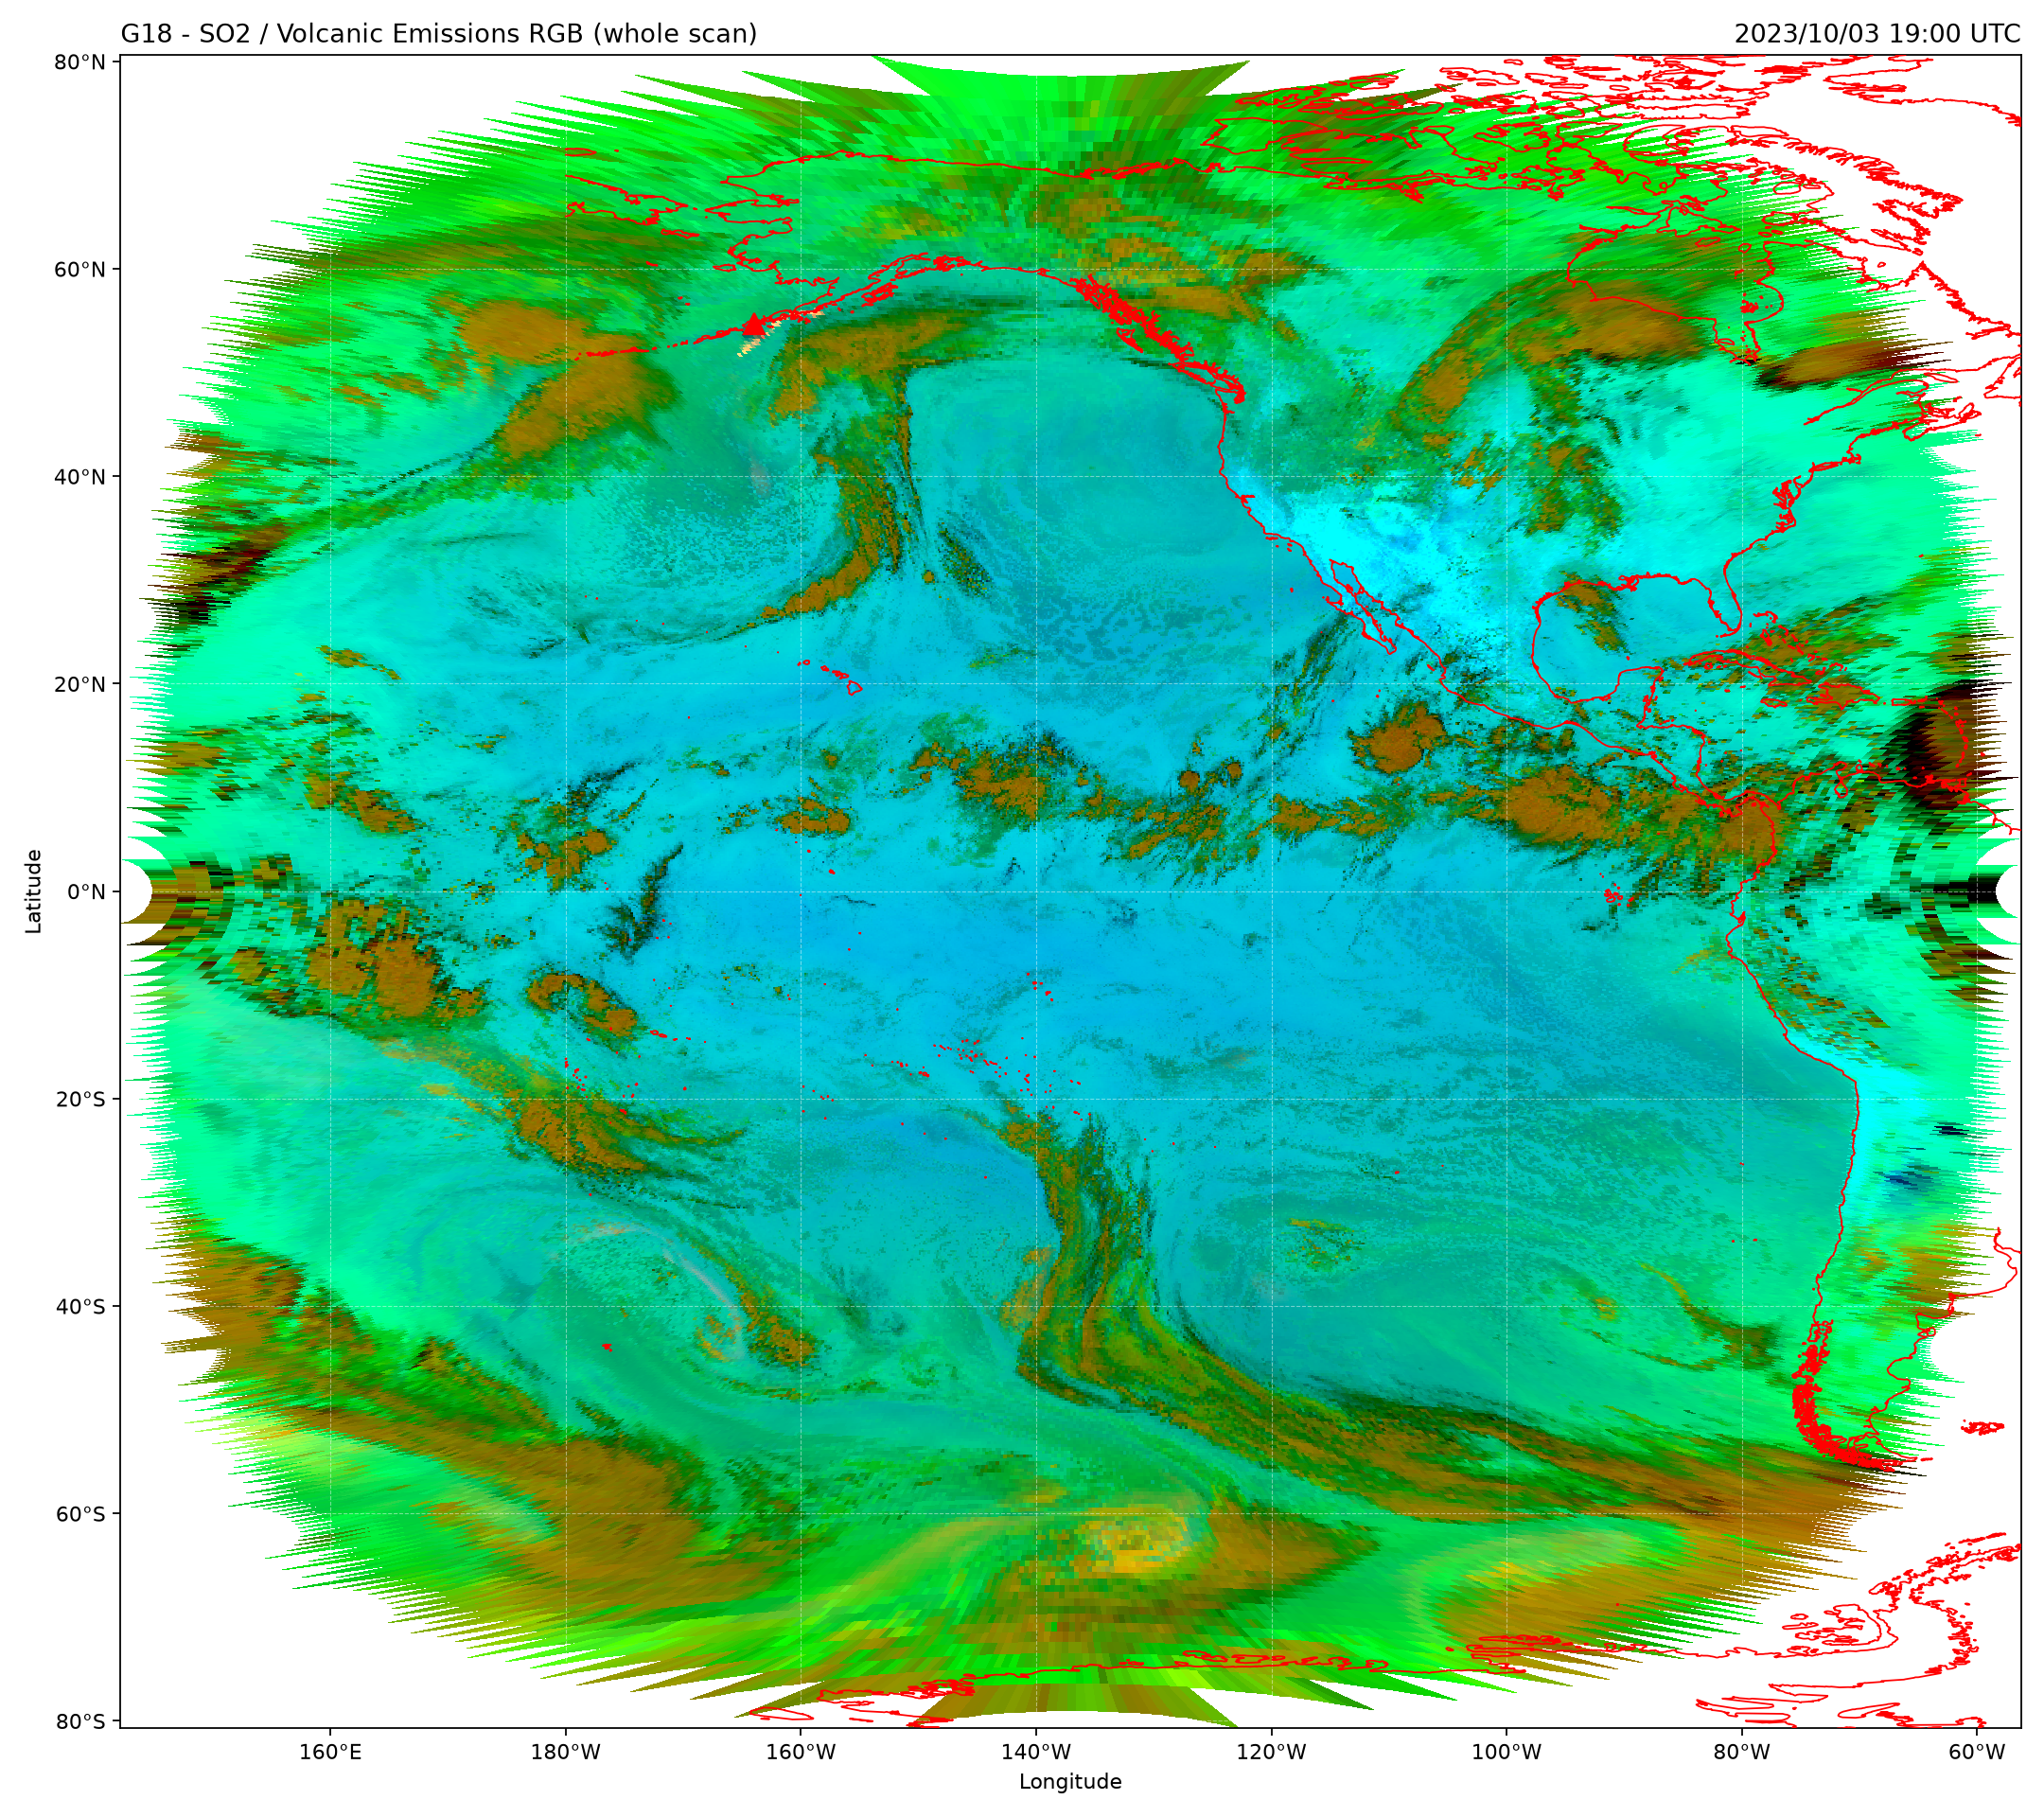

In [5]:
OUT_FULL = Path("../output/full_disk_full.png")
OUT_BOX = Path("../output/full_disk_box.png")
OUT_FULL.parent.mkdir(parents=True, exist_ok=True)

whole = gt.volcanic_emissions(files, stride=STRIDE)
print(whole)

west, east = float(np.nanmin(whole.lon_corners)), float(np.nanmax(whole.lon_corners))
south, north = float(np.nanmin(whole.lat_corners)), float(np.nanmax(whole.lat_corners))

fig, ax = figure_for(west, east, south, north)
gt.draw_rgb(ax, whole)
decorate(ax, west, east, south, north,
         "G18 - " + whole.name + " (whole scan)", whole.time)
fig.tight_layout(); fig.savefig(OUT_FULL, dpi=DPI); plt.close(fig)
display(Image(filename=str(OUT_FULL)))


## 3. Your box

In [6]:
# ---------------------------------------------------------------
# 3. YOUR BOX -- write the four numbers yourself, in decimal degrees.
# There is no preset: this is the area you choose to look at.
#
#     LON_MIN, LON_MAX, LAT_MIN, LAT_MAX   (west, east, south, north)
#
# Set BOX = None to skip the crop; step 4 then draws the whole scan again.
# The box must fall inside what this product actually observed.
# ---------------------------------------------------------------
BOX = (-169.0, -159.0, 52.5, 57.0)

print("box:", BOX)


box: (-169.0, -159.0, 52.5, 57.0)


## 4. Plot your box

<Composite SO2 / Volcanic Emissions RGB (139, 359, 3) at 2023-10-03 19:00:20.655517>


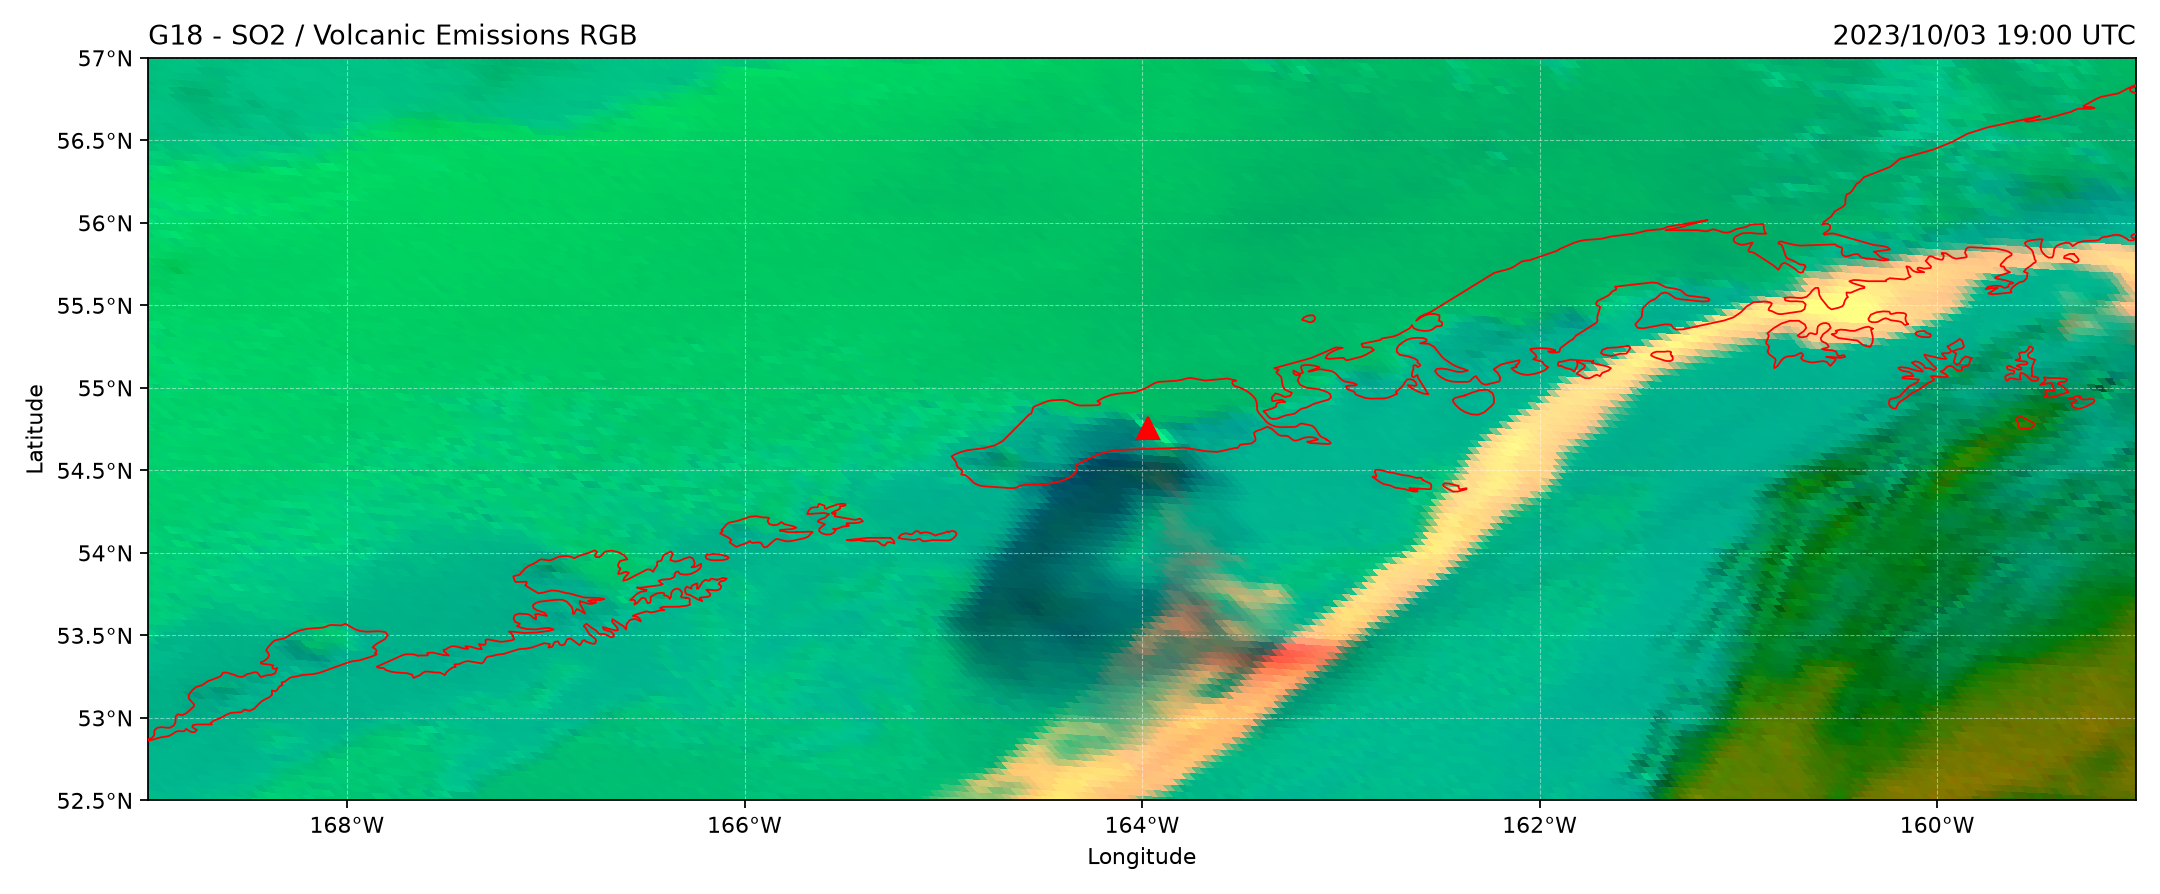

In [7]:
if BOX is None:
    print("No box set -- the whole scan is above.")
else:
    lon_min, lon_max, lat_min, lat_max = BOX
    rgb = gt.volcanic_emissions(files, lon_min, lon_max, lat_min, lat_max)
    print(rgb)

    fig, ax = figure_for(lon_min, lon_max, lat_min, lat_max)
    gt.draw_rgb(ax, rgb)
    decorate(ax, lon_min, lon_max, lat_min, lat_max,
             "G18 - " + rgb.name, rgb.time)
    fig.tight_layout(); fig.savefig(OUT_BOX, dpi=DPI); plt.close(fig)
    display(Image(filename=str(OUT_BOX)))


## Reading the colours

SO2-rich air tends to show in yellow to green tones. Thick upper-level cloud can hide the signal, and low cloud can mimic it.

See [docs/RGB.md](../docs/RGB.md).